In [1]:
import warnings
import importlib
warnings.filterwarnings('ignore')
import MisallocationAnalysis
importlib.reload(MisallocationAnalysis)
from MisallocationAnalysis import MisallocationAnalysis

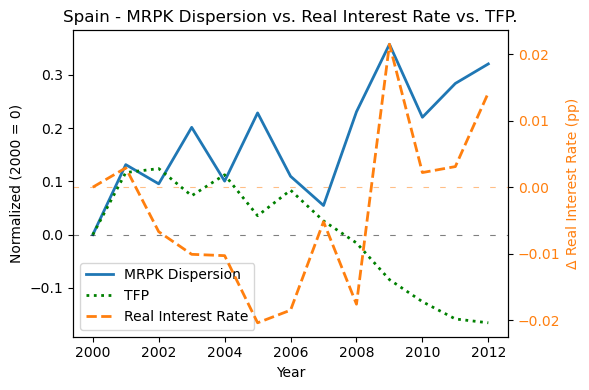

,Year,Turnover,Wages,Value Added,Firms,Employees
0,2000,0.56,0.47,0.84,0.06,0.30
1,2001,0.62,0.50,0.96,0.08,0.32
2,2002,0.65,0.53,0.98,0.09,0.34
3,2003,0.64,0.47,0.91,0.05,0.29
4,2004,0.62,0.48,0.90,0.06,0.30
5,2005,0.64,0.59,0.97,0.11,0.38
6,2006,0.62,0.58,0.92,0.12,0.38
7,2007,0.57,0.59,0.90,0.12,0.40
8,2008,0.62,0.67,0.96,0.21,0.47
9,2009,0.68,0.69,1.13,0.22,0.50


In [17]:
spain1 = MisallocationAnalysis('Spain', start = 2000, end= 2012)
spain1.plot_mrpk_tfp_realrate()
spain1.compare_df_eurostats()

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = spain1.df.copy()
print(len(df))
df = df.sort_values(['FirmName', 'year'])
 
# weight = each firm's share of total capital costs within its sector-year
df['weights'] = df['k'] / df.groupby(['sector', 'year'])['k'].transform('sum')

# calculate cost weightes sector year average MRPK
df['w log MRPK'] = df['weights'] * df['log_MRPK']
df['avg s log MRPK'] = df.groupby(['sector', 'year'])['w log MRPK'].transform('sum')
df['MRPK dev'] = df['log_MRPK'] - df['avg s log MRPK']



#create lags and consecutive logic
df['ln K'] = np.log(df['k'])
df['ln R'] = np.log(df['nvad'])
df['ln K lag'] = df.groupby('FirmName')['ln K'].shift(1) 
df['ln R lag'] = df.groupby('FirmName')['ln R'].shift(1)
df['MRPK dev lag'] = df.groupby('FirmName')['MRPK dev'].shift(1) 
df['year lag'] = df.groupby('FirmName')['year'].shift(1)
df['is consecutive'] = (df['year'] - df['year lag']) == 1

#calculate growth and average mrpk deviation
df['dR'] = np.where(
    df['is consecutive'],
    df['ln R'] - df['ln R lag'],
    np.nan
)
df['dK'] = np.where(
    df['is consecutive'],
    df['ln K'] - df['ln K lag'],
    np.nan
)
df['MRPK dev avg'] = np.where(
    df['is consecutive'],
    (df['MRPK dev'] + df['MRPK dev lag']) / 2,
      np.nan
)

# demean growth rates by sector-year (removes common sector-year shocks)
df['dR dev'] = df['dR'] - df.groupby(['sector', 'year'])['dR'].transform('mean')
df['dK dev'] = df['dK'] - df.groupby(['sector', 'year'])['dK'].transform('mean')

# decile assignment of MRPK deviation
df['decile'] = pd.qcut(df['MRPK dev avg'], 10, labels=False)

df = df[df['is consecutive']].copy()

# --- 6. regress dR_dev on dI_dev, separately per decile, weighted by cost share ---
beta_by_decile = {}
se_by_decile = {}
reg_data = df.dropna(subset=['dR dev', 'dK dev', 'decile'])
print(len(reg_data))

for k, g in reg_data.groupby('decile'):
    X = sm.add_constant(g['dK dev'])
    y = g['dR dev']
    model = sm.WLS(y, X, weights=g['weights']).fit()
    beta_by_decile[k] = model.params['dK dev']
    se_by_decile[k] = model.bse['dK dev']

results = pd.DataFrame({'beta': beta_by_decile, 'se': se_by_decile}).sort_index()
print(results)


358532
253566
         beta        se
0.0  0.347753  0.013014
1.0  0.408760  0.008521
2.0  0.388423  0.006368
3.0  0.261961  0.005604
4.0  0.284448  0.005169
5.0  0.301769  0.004669
6.0  0.354852  0.005244
7.0  0.284024  0.004338
8.0  0.212460  0.003678
9.0  0.206698  0.003725


In [57]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

df = spain1.df.copy()
print(len(df))
df = df.sort_values(['FirmName', 'year'])

#create total cost for weigh
df['total_cost'] = df['k'] + df['w'] + df['materials']
df['cost_weight'] = df['total_cost'] / df.groupby(['sector','year'])['total_cost'].transform('sum')

# share weights - use empirical cost shares
df['s_K'] = df['k'] / df['total_cost']
df['s_L'] = df['w'] / df['total_cost']
df['s_X'] = df['materials'] / df['total_cost']

# calculate cost weightes sector year average TFPR
df['wlnTFPR'] = df['cost_weight'] * df['log_TFPR']
df['meanlnTFPR'] = df.groupby(['sector', 'year'])['wlnTFPR'].transform('sum')
df['TFPRdev'] = df['log_TFPR'] - df['meanlnTFPR']

#create logs of inputs and lags
df['lnK'] = np.log(df['k'])
df['lnL'] = np.log(df['w'])
df['lnX'] = np.log(df['materials'])
df['lnR'] = np.log(df['revenue'])

#create lags and consecutive logic
df['lnKlag'] = df.groupby('FirmName')['lnK'].shift(1) 
df['lnLlag'] = df.groupby('FirmName')['lnL'].shift(1) 
df['lnXlag'] = df.groupby('FirmName')['lnX'].shift(1) 
df['lnRlag'] = df.groupby('FirmName')['lnR'].shift(1)

df['TFPRdevlag'] = df.groupby('FirmName')['TFPRdev'].shift(1) 
df['yearlag'] = df.groupby('FirmName')['year'].shift(1)
df['consecutive'] = (df['year'] - df['yearlag']) == 1


#calculate growth and average mrpk deviation
for var in ['lnK', 'lnL', 'lnX', 'lnR']:
    df[f'd{var}'] = np.where(
        df['consecutive'],
        df[var] - df[f'{var}lag'],
        np.nan
    )

df['TFPRmeandev'] = np.where(
    df['consecutive'],
    (df['TFPRdev'] + df['TFPRdevlag']) / 2,
      np.nan
)

df['decile'] = pd.qcut(df['TFPRmeandev'], 10, labels=False) + 1

#sum cost by weights
df['dlnI'] = df['s_K']*df['dlnK'] + df['s_L']*df['dlnL'] + df['s_X']*df['dlnX']

# demean growth rates by sector-year (removes common sector-year shocks)
df['dR dev'] = df['dlnR'] - df.groupby(['sector', 'year'])['dlnR'].transform('mean')
df['dI dev'] = df['dlnI'] - df.groupby(['sector', 'year'])['dlnI'].transform('mean')

df = df[df['consecutive']].copy()
print(len(df))

# --- 6. regress dR_dev on dI_dev, separately per decile, weighted by cost share ---
beta_by_decile = {}
se_by_decile = {}
reg_data = df.dropna(subset=['dR dev', 'dI dev', 'decile'])

for k, g in reg_data.groupby('decile'):
    X = sm.add_constant(g['dI dev'])
    y = g['dR dev']
    model = sm.WLS(y, X, weights=g['cost_weight']).fit()
    beta_by_decile[k] = model.params['dI dev']
    se_by_decile[k] = model.bse['dI dev']

results = pd.DataFrame({'beta': beta_by_decile, 'se': se_by_decile}).sort_index().reset_index().rename(columns={'index': 'decile'})
print('Beta Regression Results')
print(results)



358532
253566
Beta Regression Results
   decile      beta        se
0     1.0  0.729036  0.007268
1     2.0  0.793002  0.005791
2     3.0  0.721538  0.004747
3     4.0  0.748057  0.003912
4     5.0  0.716591  0.004723
5     6.0  0.857958  0.004237
6     7.0  0.829412  0.004298
7     8.0  0.802200  0.003756
8     9.0  0.837779  0.003929
9    10.0  0.814690  0.003695


In [58]:
df['decile_weight'] = df['total_cost'] / df.groupby(['decile','year'])['total_cost'].transform('sum')
df['decile_weighted_tfpr'] = df['TFPR'] * df['decile_weight']

#group deciles to get total ln tfpr per decile
decile_means = df.groupby('decile').agg(
    ln_tfpr_k=('decile_weighted_tfpr', 'sum')
).reset_index()
decile_means['ln_tfpr_k'] = np.log(decile_means['ln_tfpr_k'])
#merge with results to get beta per decile
decile_means = decile_means.merge(results, on='decile', how='left')
decile_means['lnbeta'] = np.log(decile_means['beta'])
#calculate covariance term and variance term of equation 49 in klenow 2021 to get sigma
cov_term = np.cov(decile_means['ln_tfpr_k'], decile_means['lnbeta'])[0, 1]
var_beta = decile_means['lnbeta'].var()
sigma2 = -cov_term - var_beta
sigma = np.sqrt(max(sigma2, 0))
#get epsilon for whole df from sigma
np.random.seed(0)
df['epsilon'] = np.random.normal(loc=0.0, scale=sigma, size=len(df))
#calculate corrected values
df = df.merge(decile_means, on='decile', how='left')
df['corrected MRPK'] = df['log_MRPK'] + df['lnbeta'] + df['epsilon']
df['corrected MRPL'] = df['log_MRPL'] + df['lnbeta'] + df['epsilon']


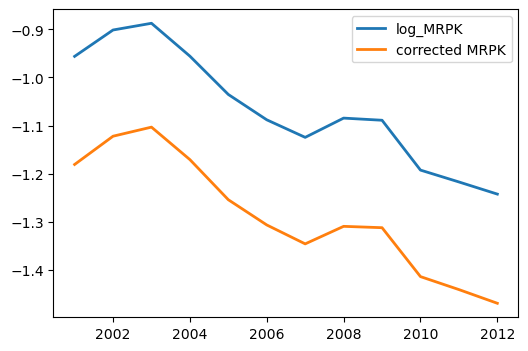

In [59]:
import matplotlib.pyplot as plt
VARS = ['log_MRPK','corrected MRPK']

plotdf = df[VARS + ['nvad',  'year']].copy()
plotdf['weight'] = plotdf['nvad'] / plotdf.groupby('year')['nvad'].transform('sum')

for var in VARS:
    plotdf[var] = plotdf[var] * plotdf['weight']

plotdf = plotdf.groupby('year')[VARS].sum().reset_index()

fig,ax1 = plt.subplots(figsize=(6,4))

for var in VARS:
    ax1.plot(plotdf["year"], plotdf[var], label=var,  linewidth=2)

plt.legend()

plt.show()